<a href="https://colab.research.google.com/github/ghkdtjdbs/Hands-on-Machine-Learning-Study/blob/main/Chapter4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4장  

이전의 챕터에서는 머신러닝 모델과 훈련 알고리즘을 블랙박스처럼 취급함  
: 내부 작동 방식을 몰라도 일을 처리할 수 있음 (몰라도 일 처리 가능한 경우 많음)  
슨데 어떻게 작동하는지 잘 이해하고 있으면 적절한 모델, 올바른 훈련 알고리즘, 작업에 맞즌 좋은 하이퍼파라미터를 빠르게 찾을 수 있음  
그리고 디버깅이나 에러를 효율적을 분석하는데도 도움이 됨

일단 선형 회귀 모델 해보자  
방법 1) 닫힌 형태의 방정식을 사용해서 가장 잘 맞는 모델 파라미터를 직접 계산  
방법 2) 경사하강법으로 파라미터를 조정하여 비용 함수를 훈련 세트에 대해 최소화 시킴  
+) 비선형 데이터셋에서 훈련시킬 수 있는 조금 더 복잡한 모델의 아항 회귀는 선형 회귀보다 파라미터가 많아서 훈련 데이터에 과대적합 되기가 쉬움 그래서 과대적합을 감지하고, 줄일 수 있는 방법도 배울거임  
그리고 분류작업에 쓰이는 로지스틱스 회귀와 소프트맥스 회귀도 볼거임

4.1 선형 회귀  
모델을 훈련 시킨다는 것은 모델이 훈련 세트에 가장 잘 맞도록 모델 파라미터를 설정하는 것  
이러기 위해서 모델이 훈련 데이터에 얼마나 잘 들어맞는지측정해야함  
RMSE가 최소화 되는 지점을 찾아야 함

4.1.1  정규 방정식  
비용함수를 최소화하는 0 값을 찾기 위한 해석적인 방법(결과를 수학적으로 얻을 수 있는 공식)은 정규 방정식

In [2]:
#정규 방정식 테스트 해보기 위해 선형 처럼 보이는 데이터 생성하기

import numpy as np

np.random.seed(42)
m = 100 #샘플 개수
X = 2 * np.random.rand(m, 1) #열 벡터
y = 4 + 3 * np.random.rand(m, 1) #열 벡터

In [3]:
#정규 방정식 사용해서 계산 해보기
#numpy 선형대수 모듈(np.linalg)에 있는 inv()함수로 역행렬 계산하고 dot()으로 행렬 곱셈

from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) #각 샘플에 x0 = 1을 추가
theta_best = np.linalg.inv(X_b.T@X_b)@X_b.T@y #@는 행렬 곱셈 연산자

In [4]:
#데이터를 생성하기 위해 사용한 함수는 y = 4 + 3x1 + 가우슨_잡음
#정규 방정식으로 계산한 값 확인하기

theta_best

array([[ 5.54079297],
       [-0.05029747]])

기대한 값과 비슷하긴 한데 잡음 때문에 원래 함수의 파라미터를 정확하게 재현 못 함  
데이터셋이 작고 잡음이 많은수록 정확한 값을 얻기 힘듦

In [5]:
#세타헷을 이용하여 예측 해보기

X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new) #각 샘플에 x0 = 1 추가 하기
y_predict = X_new_b @ theta_best
y_predict

array([[5.54079297],
       [5.44019804]])

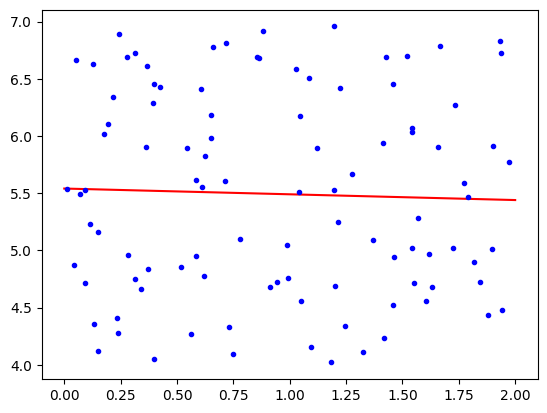

In [6]:
#모델의 예측을 그래프에 나타내기

import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-", label="예측")
plt.plot(X, y, "b.")
[...] #레이블, 축, 그리드 , 범례 추가하기
plt.show()

In [7]:
#사이킷런에서 선형 회귀를 수행하는 것은 비교적 간단

from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

lin_reg.predict(X_new)

array([[5.54079297],
       [5.44019804]])

사이킷런의 특성의 가중치(coef_)와 편향(intercept_)를 분리해서 저장함  
Linear Regression 클래스는 scipy.linalg.lstsq()함수를 기반으로 함

In [8]:
#함수 직접 호출해보기
theta_best_svd, residuals, rnak, s = np.linalg.lstsq(X, y, rcond=1e-6)
theta_best_svd

array([[4.16949805]])

In [9]:
#이 함수는 세타헥 = X+(윗 첨자)y를 계산함 X+(윗 첨자)는 X의 유사역행렬임 np.linalg.pinv()함수를 사용해 유사역행렬 직접 구할 수도 있음
np.linalg.pinv(X_b) @ y

array([[ 5.54079297],
       [-0.05029747]])

유사역행렬 자체는 특잇값 분해라고 부르는 표준 행렬 분해 기법을 사용해서 계산  
사실은 정규 방정식을 계산하는 것 보다 이게 더 효율적임  
그리고 극단적인 경우도 처리할 수 있음 만약에 m<n이거나 어떤 특정 특성이 중복되어 행렬XTX의 역행렬이 없으면 정규방정식은 안 통하는데 유사역행렬은 항상 구할 수 있음

4.1.2 계산 복잡도  
정규방정식은 (n+1)x(n+1)크기의 역행렬을 계산함  
계산 복잡도는 역행렬을 계산하는거임  
특성 수가 늘어나면 쥰내 늘어남  
학습된 선형 회귀 모델은 예측이 쁘음  
예측 계산  복잡도는 샘플 수와 특성 수에 선형적

4.2 경사 하강법  
: 여러 종류의 문제에서 최적의 해법을 찾을 수 있는 일반적인 최적화 알고리즘  
경사하강법은 비용함수를 최소화 하려고 계속 반복해서 파라미터를 조정하는 것  
0을 임의의 값으로 해서 랜덤 초기화 함  
점진적으로 변화 시키는 거  
여기서 경사 하강법학습률 에서 이 스텝이 중요한데 이거는 학습률 하이퍼파라미터로 결정 됨  
학습률이 너무 작으면 알고리즘이 맞추려고 반복 많이 해야해서 시간이 오래 걸림  
근데 학습률이 너무 크면 오바해서 적절한 해결법 못 찾음  

책에서는 비용함수가 예쁜 2차함수지만 실제 상황은 이렇게 이쁘지 않음  
그래서 완벽하게 최솟값이 되는거는 어려움  
램덤 초기화 때문에 알고리즘이 왼쪽에서 시작하면 전역 최솟값보다 덜 좋은 지역 최솟값에 수렴함  
근데 만약에 오른 쪽에서 시작하면 평탄한 지역을 길게 지나야 해서 무튼 결국 전역 최솟값에 도달 못 함  
근데 다행히도 선형 회귀를 위한 MSE 비용함수는 곡선에서 어떤 두 점을 선택해 선을 그어도곡선을 가로지르지 않는 볼록함수임  
그니까 이 말은 지역 최솟값이 없고 하나의 전역 최솟값만 있다는 뜻  
그리고 기울기가 갑자기 변하지 않음  
이렇기 때문에 경사 하강법이 전역 최솟값에 가깝게 접근 할 수 있음  
근데 비용함수는 그릇모양이 맞긴 맞거든 근데 특성들의 스케일이 매우 다르면 길쭉해질 수도  
이러면 최솟값에 도달 할 수는 있어, 있는데 시간이 오래 걸림  


4.2.1 배치 경사 하강법  
경사 하강법을 구현하려면 각 모델 파라미터 세타에다가 비용함수의 그레이디언트를 계산 해야 함  
그니까 쉽게 말하면 세타가 바뀔 떄 마다 비용함수가 얼마나 바뀌는지 계산 해야함  
이거를 편도함수라고 함

In [10]:
#편도함수 간단하게 구현해보기
eta = 0.1 #학습률
n_epochs = 1000
m = len(X_b) #샘플 개수

np.random.seed(42)
theta = np.random.randn(2,1) #랜덤 초기화(모델 파라미터를 랜덤하게 초기화 하는거임)

for epoch in range(n_epochs):
  gradients = 2/m * X_b.T @ (X_b @ theta - y)
  theta = theta - eta * gradients

여기서 훈련 세트를 한 번 반복하는거를 에포크(epoch)라고 함

In [11]:
#계산된 세타 확인 하기
theta

array([[ 5.54079297],
       [-0.05029747]])

근데 여기서 학습률을 바꿔보면?  
학습률이 너무 많아도, 적어도 안 좋음 최적으로 찾아야 하는데  
적절한 학습률을 찾기 위해 그리드 서치를 사용  
근데 그리드 서치에서 수렴하는 데 너무 오래 걸리는 모델이 제외될 수 있도록 반복 횟수 제한 해야됨  

반복 횟수 정하기  
반복 횟수가 너무 적으면 최저점 가기 전에 멈춤  
너무 크면 모델 파라미터가 더는 변하지 않는 동안에 시간을 낭비하게 됨  
해결책은 반복 횟수를 아주 크게 지정하고 그레이디언트 벡터가 아주 작아지면(백터의 스템이 어떤 허용 오차)보다 작아지면 경사 하강법이 거의 최솟값에 도달했다는 뜻이니까 알고리즘을 중지하면 됨

4.2.2 확률적 경사 하강법  
배치 경사 하강법의 가장 큰 문제는 매 스텝에서 전체 훈련 세트를 사용해 그레이디언트를 계산 해야함  
-> 훈련 세트가 커지면 매우 즈려짐  
근데 이거랑 반대로 확률적 경사하강법은 매 스텝에서 한 개의 샘플을 랜덤으로 선택하고 그 하나의 샘플에 대한 그레이디언트를 계산함  
그니까 이렇게 하면 한번에 하나의 샘플을 처리하면 매 반복에서 다뤄야 할 데이터가 매우 적어서 알고리즘이 훨씬 빠름  
매 반복에서 하나의 샘플만 메모리에 있ㅇ면 되니까 큰 훈령도 시킬 수 있음